<a href="https://colab.research.google.com/github/Ikenna1414/Learning_Stock_Price_Signals_from_Candlestick_Chart_via_Vision_Transformer/blob/main/alternate%20image%20generation/Updated-version-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AI_in_Finance_Project'))

['validation', 'test']


In [ ]:
'''# ── FULL PREPROCESSING PIPELINE: New CRSP data with split adjustment ──────────
# #LEARNING: The old file was missing dlyfacprc (price adjustment factor)
# #LEARNING: dlyfacprc is CRSP's cumulative factor to adjust for stock splits
# #LEARNING: Correct formula: adjusted_price = raw_price / dlyfacprc
# #LEARNING: This replaces our old cumproduct(1+RET) approach which was unreliable
# #LEARNING: We filter issuertype='ACSH' and sharetype='NS' for common stocks only
# #LEARNING: chunksize reads file in pieces to avoid RAM overflow on Colab 12GB
# #LEARNING: tqdm shows progress bar so we know code is still running
# #LEARNING: os.makedirs creates folder if it doesn't exist, exist_ok avoids error if it does

import pandas as pd
import numpy as np
import os
from tqdm import tqdm

new_crsp_path = '/content/drive/MyDrive/AI_in_Finance_Project/ewr73aijzrmdlrr3.csv'
os.makedirs('data/stock', exist_ok=True)

# ── Step 1: Peek at columns first ─────────────────────────────────────────────
df_peek = pd.read_csv(new_crsp_path, nrows=3)
print("Columns:", df_peek.columns.tolist())
print("\nSample rows:")
print(df_peek)
print("\n")

# ── Step 2: Read full file in chunks, keep only common stocks ─────────────────
# #LEARNING: We collect all data first, then process per stock
# #LEARNING: isin() filters rows where value matches any item in the list
print("Reading file in chunks...")
chunks = []
chunk_size = 200_000

for chunk in pd.read_csv(new_crsp_path, chunksize=chunk_size,
                          low_memory=False):

    # Rename columns to standard names we use throughout the pipeline
    # #LEARNING: rename() maps old column names to new ones
    chunk = chunk.rename(columns={
        'permno':      'PERMNO',
        'dlycaldt':    'date',
        'primaryexch': 'EXCHCD',
        'dlyopen':     'OPENPRC',
        'dlyhigh':     'ASKHI',
        'dlylow':      'BIDLO',
        'dlyclose':    'PRC',
        'dlyvol':      'VOL',
        'dlyret':      'RET',
        'shrout':      'SHROUT',
        'dlyfacprc':   'CFACPR',
        'issuertype':  'ISSUERTYPE',
        'sharetype':   'SHARETYPE',
    })

    # Filter to common stocks only
    # #LEARNING: ISSUERTYPE 'ACSH' = common shares, SHARETYPE 'NS' = normal shares
    # This removes ETFs, REITs, preferred shares, warrants etc.
    if 'ISSUERTYPE' in chunk.columns:
        chunk = chunk[chunk['ISSUERTYPE'] == 'ACSH']
    if 'SHARETYPE' in chunk.columns:
        chunk = chunk[chunk['SHARETYPE'] == 'NS']

    # Filter to major exchanges only
    # #LEARNING: N=NYSE, A=AMEX, Q=Nasdaq (new format uses letters not numbers)
    if 'EXCHCD' in chunk.columns:
        chunk = chunk[chunk['EXCHCD'].isin(['N', 'A', 'Q'])]

    if len(chunk) > 0:
        chunks.append(chunk)

crsp = pd.concat(chunks, ignore_index=True)
print(f"Total rows after filtering: {len(crsp):,}")
print(f"Unique stocks: {crsp['PERMNO'].nunique():,}")

# ── Step 3: Clean data types ───────────────────────────────────────────────────
# #LEARNING: astype() converts column to specific data type
# #LEARNING: pd.to_numeric with errors='coerce' turns invalid values to NaN
crsp['OPENPRC'] = pd.to_numeric(crsp['OPENPRC'], errors='coerce')
crsp['ASKHI']   = pd.to_numeric(crsp['ASKHI'],   errors='coerce')
crsp['BIDLO']   = pd.to_numeric(crsp['BIDLO'],   errors='coerce')
crsp['PRC']     = pd.to_numeric(crsp['PRC'],     errors='coerce')
crsp['VOL']     = pd.to_numeric(crsp['VOL'],     errors='coerce')
crsp['RET']     = pd.to_numeric(crsp['RET'],     errors='coerce')
crsp['CFACPR']  = pd.to_numeric(crsp['CFACPR'],  errors='coerce')
crsp['PERMNO']  = crsp['PERMNO'].astype(int)
crsp['date']    = pd.to_datetime(crsp['date'])

# Negative PRC means bid/ask average — set to NaN
crsp.loc[crsp['PRC'] < 0, 'PRC'] = np.nan

# ── Step 4: Process each stock and save as pkl ────────────────────────────────
# #LEARNING: groupby splits dataframe into groups by PERMNO
# much faster than filtering inside a loop for every stock
print("\nProcessing stocks and saving pkl files...")

no_lst = crsp['PERMNO'].unique()

for permno in tqdm(no_lst):
    temp = crsp[crsp['PERMNO'] == permno].copy()
    temp = temp.sort_values(by='date').reset_index(drop=True)

    # Skip stocks with no valid close prices
    if temp['PRC'].isna().all():
        continue

    # Skip stocks with too few rows
    if len(temp) < 45:
        continue

    # ── THE KEY FIX: Use dlyfacprc to get split-adjusted prices ──────────────
    # #LEARNING: CFACPR is cumulative adjustment factor from CRSP
    # #LEARNING: Dividing by CFACPR correctly undoes all splits and dividends
    # #LEARNING: This is cleaner and more reliable than cumproduct(1+RET)
    # Replace zero or NaN adjustment factors with 1 (no adjustment)
    temp['CFACPR'] = temp['CFACPR'].replace(0, np.nan).fillna(1)

    temp['ADJ_CLOSE'] = temp['PRC']    / temp['CFACPR']
    temp['ADJ_OPEN']  = temp['OPENPRC']/ temp['CFACPR']
    temp['ADJ_HIGH']  = temp['ASKHI']  / temp['CFACPR']
    temp['ADJ_LOW']   = temp['BIDLO']  / temp['CFACPR']

    # Zero volume days → NaN prices (no real trading happened)
    # #LEARNING: boolean mask to find zero volume rows
    no_trade = (temp['VOL'] == 0) | (temp['VOL'].isna())
    temp.loc[no_trade, 'ADJ_OPEN']  = np.nan
    temp.loc[no_trade, 'ADJ_HIGH']  = np.nan
    temp.loc[no_trade, 'ADJ_LOW']   = np.nan
    temp.loc[no_trade, 'ADJ_CLOSE'] = np.nan

    # Keep only what image generation needs
    temp = temp[['date', 'ADJ_OPEN', 'ADJ_HIGH', 'ADJ_LOW', 'ADJ_CLOSE', 'VOL']].copy()
    temp.columns = ['date', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
    temp.set_index('date', inplace=True)
    temp.index = pd.to_datetime(temp.index)

    temp.to_pickle(f'data/stock/{permno}.pkl')

# ── Step 5: Verify output ─────────────────────────────────────────────────────
pkl_files = os.listdir('data/stock')
print(f"\nTotal pkl files saved: {len(pkl_files)}")
print(f"Sample files: {pkl_files[:5]}")

# Check one pkl looks right
sample_pkl = pd.read_pickle(f'data/stock/{pkl_files[0]}')
print(f"\nSample pkl shape: {sample_pkl.shape}")
print(sample_pkl.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AI_in_Finance_Project/ewr73aijzrmdlrr3.csv'

In [ ]:
# ── FULL PREPROCESSING PIPELINE: Fixed column names ──────────────────────────
# #LEARNING: Always peek at data first to confirm exact column names
# #LEARNING: New CRSP format uses CamelCase column names e.g. DlyClose not dlyclose
# #LEARNING: IssuerType = CORP means corporation (common stock)
# #LEARNING: ShareType = NS means normal shares (not preferred/warrant etc)
# #LEARNING: PrimaryExch N=NYSE, A=AMEX, Q=Nasdaq

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from collections import defaultdict

new_crsp_path = '/content/drive/MyDrive/AI_in_Finance_Project/ewr73aijzrmdlrr3.csv'
os.makedirs('data/stock', exist_ok=True)

print("Starting chunked processing...")

stock_data = defaultdict(list)
chunk_size = 100_000
total_rows = 0
kept_rows = 0

for chunk in pd.read_csv(new_crsp_path, chunksize=chunk_size, low_memory=False):
    total_rows += len(chunk)

    # Rename columns to our standard names
    # #LEARNING: rename() maps old column names to new ones we use throughout pipeline
    chunk = chunk.rename(columns={
        'PERMNO':       'PERMNO',
        'DlyCalDt':     'date',
        'PrimaryExch':  'EXCHCD',
        'DlyOpen':      'OPENPRC',
        'DlyHigh':      'ASKHI',
        'DlyLow':       'BIDLO',
        'DlyClose':     'PRC',
        'DlyVol':       'VOL',
        'DlyRet':       'RET',
        'ShrOut':       'SHROUT',
        'DlyFacPrc':    'CFACPR',
        'IssuerType':   'ISSUERTYPE',
        'ShareType':    'SHARETYPE',
    })

    # Filter common stocks on major exchanges
    # #LEARNING: CORP = corporation = common stock in new CRSP format
    # #LEARNING: NS = normal shares, filters out preferred shares and warrants
    # #LEARNING: N=NYSE, A=AMEX, Q=Nasdaq
    chunk = chunk[chunk['ISSUERTYPE'] == 'CORP']
    chunk = chunk[chunk['SHARETYPE'] == 'NS']
    chunk = chunk[chunk['EXCHCD'].isin(['N', 'A', 'Q'])]

    kept_rows += len(chunk)

    # Accumulate rows per stock
    for permno, group in chunk.groupby('PERMNO'):
        stock_data[permno].append(group)

print(f"Total rows read: {total_rows:,}")
print(f"Rows after filtering: {kept_rows:,}")
print(f"Unique stocks found: {len(stock_data):,}")

# ── Process each stock and save pkl ──────────────────────────────────────────
print("\nSaving pkl files...")
saved = 0
skipped = 0

for permno, chunks_list in tqdm(stock_data.items()):

    temp = pd.concat(chunks_list, ignore_index=True)
    temp = temp.sort_values(by='date').reset_index(drop=True)

    if len(temp) < 45:
        skipped += 1
        continue

    # Clean data types
    # #LEARNING: errors='coerce' converts invalid values to NaN instead of crashing
    for col in ['OPENPRC', 'ASKHI', 'BIDLO', 'PRC', 'VOL', 'CFACPR']:
        temp[col] = pd.to_numeric(temp[col], errors='coerce')

    # Negative PRC = bid/ask average, not a real trade price
    temp.loc[temp['PRC'] < 0, 'PRC'] = np.nan

    if temp['PRC'].isna().all():
        skipped += 1
        continue

    # ── KEY FIX: Split adjustment using DlyFacPrc ─────────────────────────────
    # #LEARNING: DlyFacPrc is CRSP's cumulative factor to adjust for stock splits
    # #LEARNING: adjusted_price = raw_price / DlyFacPrc
    # #LEARNING: If factor is 2.0, it means stock has split 2-for-1 at some point
    # #LEARNING: Dividing by factor correctly scales all historical prices
    # #LEARNING: Replace 0 or NaN with 1 meaning no adjustment needed
    temp['CFACPR'] = temp['CFACPR'].replace(0, np.nan).fillna(1)

    temp['ADJ_CLOSE'] = temp['PRC']     / temp['CFACPR']
    temp['ADJ_OPEN']  = temp['OPENPRC'] / temp['CFACPR']
    temp['ADJ_HIGH']  = temp['ASKHI']   / temp['CFACPR']
    temp['ADJ_LOW']   = temp['BIDLO']   / temp['CFACPR']

    # Zero volume days → NaN (no real trading happened)
    no_trade = (temp['VOL'] == 0) | (temp['VOL'].isna())
    temp.loc[no_trade, ['ADJ_OPEN', 'ADJ_HIGH', 'ADJ_LOW', 'ADJ_CLOSE']] = np.nan

    # Save pkl with only what image generation needs
    out = temp[['date', 'ADJ_OPEN', 'ADJ_HIGH', 'ADJ_LOW', 'ADJ_CLOSE', 'VOL']].copy()
    out.columns = ['date', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
    out.set_index('date', inplace=True)
    out.index = pd.to_datetime(out.index)
    out.to_pickle(f'data/stock/{permno}.pkl')
    saved += 1

print(f"\nPKL files saved: {saved}")
print(f"Stocks skipped: {skipped}")

# Verify one file looks correct
pkl_files = os.listdir('data/stock')
sample = pd.read_pickle(f'data/stock/{pkl_files[0]}')
print(f"\nSample pkl shape: {sample.shape}")
print(sample.head())
print(f"\nAny NaN in CLOSE: {sample['CLOSE'].isna().sum()} out of {len(sample)} rows")

Starting chunked processing...
Total rows read: 54,035,694
Rows after filtering: 39,046,289
Unique stocks found: 17,314

Saving pkl files...


100%|██████████| 17314/17314 [02:56<00:00, 97.87it/s] 


PKL files saved: 17157
Stocks skipped: 157

Sample pkl shape: (3119, 5)
             OPEN    HIGH     LOW   CLOSE      VOL
date                                              
1993-05-21  3.000  3.0000  2.6250  2.8750  34300.0
1993-05-24  2.875  2.8750  2.6250  2.6250  12000.0
1993-05-25  2.875  2.8750  2.5000  2.8750  28000.0
1993-05-26  2.625  2.8750  2.5000  2.5000  32738.0
1993-05-27  2.500  2.6875  2.4375  2.5625  11820.0

Any NaN in CLOSE: 3 out of 3119 rows


In [ ]:
#TEST RUNS FINE, NO NEED TO RERUN
# ── STEP: Generate candlestick images from real CRSP data (test 10 stocks) ────
# #LEARNING: We test on 10 stocks first before running all 17,157
# #LEARNING: glob() finds all files matching a pattern
# #LEARNING: Always test on small sample before full scale run

import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from glob import glob
from tqdm import tqdm

os.makedirs('data/image/rgb', exist_ok=True)

def price_scaling(dataframe, size):
    # #LEARNING: Normalizes prices to fit within image pixel range 0 to size
    # #LEARNING: This removes absolute price level — model learns shape not price
    if np.nanmin(dataframe) == np.nanmax(dataframe):
        return np.round((dataframe) / (np.nanmax(dataframe)) * size//2, 0).astype(int)
    else:
        return np.round((dataframe - np.nanmin(dataframe)) / (np.nanmax(dataframe) - np.nanmin(dataframe)) * size, 0).astype(int)

def vol_scaling(dataframe, size):
    # #LEARNING: Normalizes volume to fit within volume panel pixel range 0 to size
    dataframe = dataframe.copy()
    if dataframe.max().values == 0:
        dataframe['VOL'] = [0] * len(dataframe)
        return dataframe
    scaled_vol = (np.ceil((dataframe / dataframe.max()) / (1 / size))).astype(int)
    return scaled_vol

def pickle_to_rgbimage(csv_path):
    df = pd.read_pickle(csv_path)

    if len(df[~df['CLOSE'].isna()]) == 0:
        return
    df = df[df[~df['CLOSE'].isna()].index[0]:].copy()
    if len(df) < 45:
        return
    if df.isna().iloc[-1]['VOL']:
        df = df.iloc[:-1].copy()

    df['CLOSE'] = df['CLOSE'].ffill()
    df['OPEN']  = df['OPEN'].fillna(df['CLOSE'].shift(1))
    df['HIGH']  = df['HIGH'].fillna(df['CLOSE'])
    df['LOW']   = df['LOW'].fillna(df['CLOSE'])
    df['MA20_CLOSE'] = df['CLOSE'].rolling(window=20, min_periods=1).mean()

    conditions = [
        (df['CLOSE'] - df['OPEN'] > 0),
        (df['CLOSE'] - df['OPEN'] < 0),
        (df['CLOSE'] - df['OPEN'] == 0)
    ]
    choices = ['green', 'red', 'gray']
    df['COLOR'] = np.select(conditions, choices, default='nan')
    df = df.iloc[19:].copy()

    for i in range(25, len(df) + 1):
        temp = df.iloc[i-25:i].copy()
        if len(temp) < 25:
            continue
        if temp['VOL'].isna().sum() > 0:
            continue

        scaled_price = price_scaling(temp[['OPEN','HIGH','LOW','CLOSE','MA20_CLOSE']], 159)
        scaled_vol   = vol_scaling(temp[['VOL']], 63)
        colors       = temp['COLOR'].values

        image_matrix = np.zeros((224, 224, 3), dtype=np.uint8)
        candle_width = 6
        space_width  = 3
        ma20_matrix  = np.zeros((224, 224, 3), dtype=np.uint8)

        for index in range(len(scaled_price)):
            if index < len(scaled_price) - 1:
                MA20_px_today    = scaled_price.iloc[index]['MA20_CLOSE'] + 64
                MA20_px_tomorrow = scaled_price.iloc[index + 1]['MA20_CLOSE'] + 64
                start_x_today    = 1 + index * (candle_width + space_width) + candle_width // 2
                start_x_tomorrow = 1 + (index + 1) * (candle_width + space_width) + candle_width // 2
                cv2.line(ma20_matrix,
                         (start_x_today, MA20_px_today),
                         (start_x_tomorrow, MA20_px_tomorrow),
                         (0, 0, 255), 1)

        blue_pixels = np.where((ma20_matrix == [0, 0, 255]).all(axis=2))
        for y, x in zip(blue_pixels[0], blue_pixels[1]):
            if y > 0:
                ma20_matrix[y-1, x] = [0, 0, 255]
            if y < ma20_matrix.shape[0] - 1:
                ma20_matrix[y+1, x] = [0, 0, 255]

        image_matrix = ma20_matrix

        for index in range(len(scaled_price)):
            open_px  = scaled_price.iloc[index]['OPEN']  + 64
            close_px = scaled_price.iloc[index]['CLOSE'] + 64
            high_px  = scaled_price.iloc[index]['HIGH']  + 64
            low_px   = scaled_price.iloc[index]['LOW']   + 64
            start_box_y = min(open_px, close_px)
            end_box_y   = max(open_px, close_px)
            color       = colors[index]
            start_x     = 1 + index * (candle_width + space_width)

            if color == 'gray':
                rgb = np.array([64, 64, 64]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] = np.minimum(
                    image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] + rgb, 255)
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] = np.minimum(
                    image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] + rgb, 255)
            else:
                rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else np.array([0,255,0]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] += rgb
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] += rgb

        for index in range(len(scaled_vol)):
            vol_pox = scaled_vol.iloc[index]['VOL']
            color   = colors[index]
            rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                  np.array([0,255,0]).astype(np.uint8) if color=='green' else \
                  np.array([64,64,64]).astype(np.uint8)
            start_x = 1 + index * (candle_width + space_width)
            image_matrix[0:vol_pox, start_x:start_x+candle_width, :] += rgb

        image_matrix = np.flipud(image_matrix)
        image_matrix[image_matrix == 64]  = 128
        image_matrix[image_matrix == 63]  = 192
        image_matrix[image_matrix == 127] = 192
        image_matrix[image_matrix == 254] = 255
        image_matrix[160, :, :] = 0

        candle_image = Image.fromarray(image_matrix, 'RGB')
        path = 'data/image/rgb/' + str(temp.index[-1]).split(' ')[0] + '/' + csv_path.split('/')[-1].split('.pkl')[0] + '.png'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        candle_image.save(path)

# Test on 10 stocks first
stock_list = glob('data/stock/*.pkl')
stock_list.sort()
print(f"Total stocks available: {len(stock_list)}")
print("Testing on first 10 stocks...")

for path in tqdm(stock_list[:10]):
    pickle_to_rgbimage(path)

images = glob('data/image/rgb/**/*.png', recursive=True)
print(f"\nImages generated: {len(images)}")
print(f"Sample: {images[0]}")

Total stocks available: 17157
Testing on first 10 stocks...


Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_22603/2497737399.py:132: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_22603/2497737399.py:132: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_22603/2497737399.py:132: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_22603/2497737399.py:132: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_22603/2497737399.py:132: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, '


Images generated: 24029
Sample: data/image/rgb/1994-09-13/10016.png


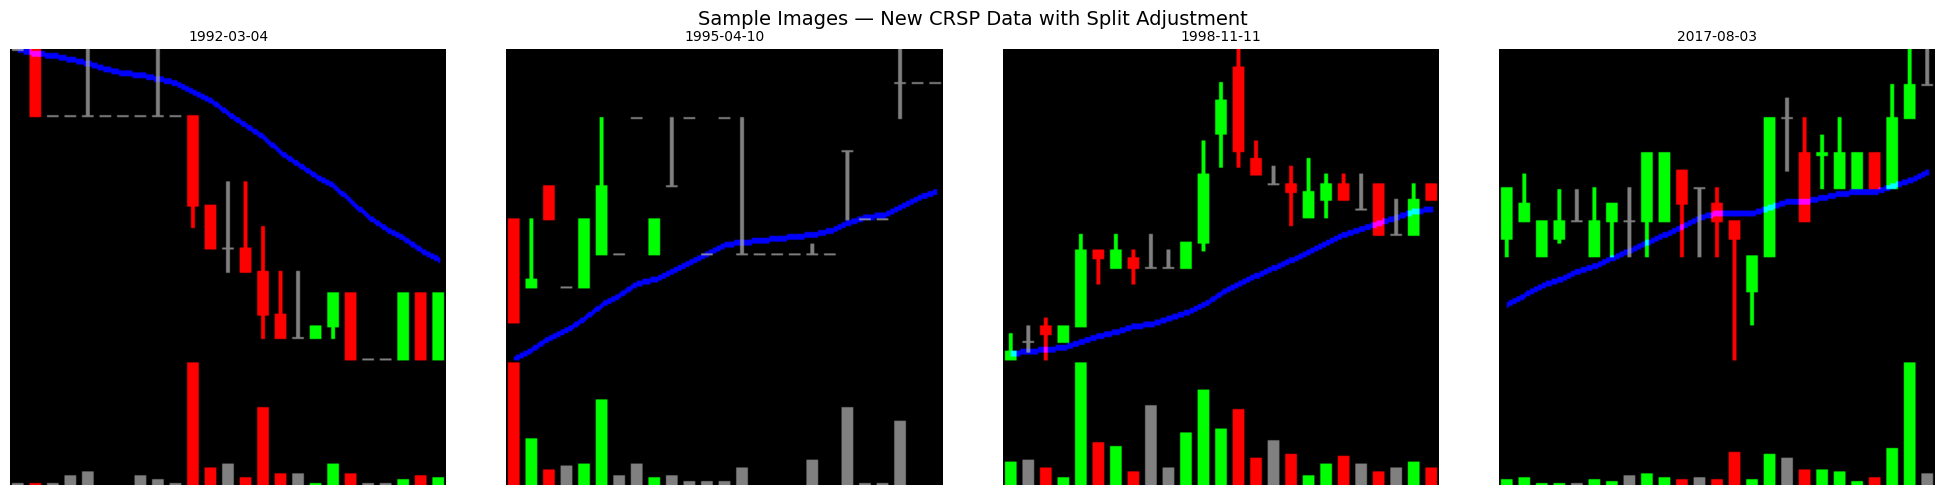

If images look clean with no sudden jumps, we are good to run full pipeline


In [ ]:
#VERIFICATION DONE, NO NEED TO RE VERIFY OR RE RUN
# ── STEP: Visually verify a generated image ───────────────────────────────────
# #LEARNING: Always visually check output before scaling up
# #LEARNING: Look for clean continuous price movement, no sudden jumps from splits

import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

images = glob('data/image/rgb/**/*.png', recursive=True)
images.sort()

# Show 4 images from different time periods
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Sample Images — New CRSP Data with Split Adjustment', fontsize=14)

sample_indices = [0, len(images)//4, len(images)//2, -1]

for ax, idx in zip(axes, sample_indices):
    img = Image.open(images[idx])
    ax.imshow(img)
    ax.set_title(images[idx].split('/')[-2], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("If images look clean with no sudden jumps, we are good to run full pipeline")

In [ ]:
import cv2
from PIL import Image
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from glob import glob
import time # Import time for retries

BASE_OUT = '/content/drive/MyDrive/AI_in_Finance_Project'

# Create output folders
for split in ['validation', 'test']:
    for label in ['up', 'down']:
        os.makedirs(f'{BASE_OUT}/{split}/{label}', exist_ok=True)
print("Folders created")

# ── Split boundaries ──────────────────────────────────────────────────────────
BATCH_START    = pd.Timestamp('2001-01-01')
VALIDATION_END = pd.Timestamp('2009-12-31')
BATCH_END      = pd.Timestamp('2020-12-31')

def get_split(date):
    """Returns validation/test based on date. None = skip."""
    if date < BATCH_START:
        return None           # skip pre-2001
    elif date <= VALIDATION_END:
        return 'validation'   # 2001-2009
    elif date <= BATCH_END:
        return 'test'         # 2010-2020
    else:
        return None           # skip post-2020

# ── Price and volume scaling ──────────────────────────────────────────────────
def price_scaling(dataframe, size):
    """Normalizes prices to pixel range — model learns shape not price level"""
    if np.nanmin(dataframe) == np.nanmax(dataframe):
        return np.round((dataframe) / (np.nanmax(dataframe)) * size//2, 0).astype(int)
    else:
        return np.round(
            (dataframe - np.nanmin(dataframe)) /
            (np.nanmax(dataframe) - np.nanmin(dataframe)) * size, 0
        ).astype(int)

def vol_scaling(dataframe, size):
    """Normalizes volume — highest day = full panel height"""
    dataframe = dataframe.copy()
    if dataframe.max().values == 0:
        dataframe['VOL'] = [0] * len(dataframe)
        return dataframe
    scaled_vol = (np.ceil((dataframe / dataframe.max()) / (1 / size))).astype(int)
    return scaled_vol

# ── Main image generation function ───────────────────────────────────────────
def generate_and_save_images(pkl_path):
    """
    Reads one stock pkl file, slides 25-day window across history,
    draws 224x224 RGB candlestick image per window, labels using
    20-day forward return, saves to correct split/label folder.
    Only generates images for windows ending 2001-2020.
    """
    permno = pkl_path.split('/')[-1].split('.pkl')[0]
    df = pd.read_pickle(pkl_path)

    if len(df[~df['CLOSE'].isna()]) == 0:
        return
    df = df[df[~df['CLOSE'].isna()].index[0]:].copy()
    if len(df) < 45:
        return
    if df.isna().iloc[-1]['VOL']:
        df = df.iloc[:-1].copy()

    # Handle missing values
    df['CLOSE'] = df['CLOSE'].ffill()
    df['OPEN']  = df['OPEN'].fillna(df['CLOSE'].shift(1))
    df['HIGH']  = df['HIGH'].fillna(df['CLOSE'])
    df['LOW']   = df['LOW'].fillna(df['CLOSE'])

    # 20-day moving average — becomes blue line in chart
    df['MA20_CLOSE'] = df['CLOSE'].rolling(window=20, min_periods=1).mean()

    # Candle color: green=up, red=down, gray=flat
    conditions = [
        (df['CLOSE'] - df['OPEN'] > 0),
        (df['CLOSE'] - df['OPEN'] < 0),
        (df['CLOSE'] - df['OPEN'] == 0)
    ]
    df['COLOR'] = np.select(conditions, ['green', 'red', 'gray'], default='nan')

    # Skip first 19 rows — MA20 needs 20 days warmup
    df = df.iloc[19:].copy()

    for i in range(25, len(df) + 1):
        temp = df.iloc[i-25:i].copy()

        if len(temp) < 25:
            continue
        if temp['VOL'].isna().sum() > 0:
            continue

        # Check if window end date is in our target range
        window_end_date = temp.index[-1]
        split = get_split(window_end_date)
        if split is None:
            continue

        # 20-day forward return label
        window_end_loc = i - 1
        if window_end_loc + 20 >= len(df):
            continue

        price_today  = df.iloc[window_end_loc]['CLOSE']
        price_future = df.iloc[window_end_loc + 20]['CLOSE']

        if pd.isna(price_today) or pd.isna(price_future):
            continue

        forward_return = (price_future - price_today) / price_today
        label = 'up' if forward_return > 0 else 'down'

        # Draw image pixel by pixel
        scaled_price = price_scaling(temp[['OPEN','HIGH','LOW','CLOSE','MA20_CLOSE']], 159)
        scaled_vol   = vol_scaling(temp[['VOL']], 63)
        colors       = temp['COLOR'].values

        # Black 224x224 canvas
        image_matrix = np.zeros((224, 224, 3), dtype=np.uint8)
        candle_width = 6
        space_width  = 3
        ma20_matrix  = np.zeros((224, 224, 3), dtype=np.uint8)

        # Draw MA20 blue line
        for index in range(len(scaled_price)):
            if index < len(scaled_price) - 1:
                MA20_px_today    = scaled_price.iloc[index]['MA20_CLOSE'] + 64
                MA20_px_tomorrow = scaled_price.iloc[index + 1]['MA20_CLOSE'] + 64
                start_x_today    = 1 + index * (candle_width + space_width) + candle_width // 2
                start_x_tomorrow = 1 + (index + 1) * (candle_width + space_width) + candle_width // 2
                cv2.line(ma20_matrix,
                         (start_x_today, MA20_px_today),
                         (start_x_tomorrow, MA20_px_tomorrow),
                         (0, 0, 255), 1)

        # Thicken MA20 line by 1px vertically
        blue_pixels = np.where((ma20_matrix == [0, 0, 255]).all(axis=2))
        for y, x in zip(blue_pixels[0], blue_pixels[1]):
            if y > 0:
                ma20_matrix[y-1, x] = [0, 0, 255]
            if y < ma20_matrix.shape[0] - 1:
                ma20_matrix[y+1, x] = [0, 0, 255]

        image_matrix = ma20_matrix

        # Draw price candles
        for index in range(len(scaled_price)):
            open_px  = scaled_price.iloc[index]['OPEN']  + 64
            close_px = scaled_price.iloc[index]['CLOSE'] + 64
            high_px  = scaled_price.iloc[index]['HIGH']  + 64
            low_px   = scaled_price.iloc[index]['LOW']   + 64
            start_box_y = min(open_px, close_px)
            end_box_y   = max(open_px, close_px)
            color   = colors[index]
            start_x = 1 + index * (candle_width + space_width)

            if color == 'gray':
                rgb = np.array([64, 64, 64]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] = np.minimum(
                    image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] + rgb, 255)
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] = np.minimum(
                    image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] + rgb, 255)
            else:
                rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                      np.array([0,255,0]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] += rgb
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] += rgb

        # Draw volume bars
        for index in range(len(scaled_vol)):
            vol_pox = scaled_vol.iloc[index]['VOL']
            color   = colors[index]
            rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                  np.array([0,255,0]).astype(np.uint8) if color=='green' else \
                  np.array([64,64,64]).astype(np.uint8)
            start_x = 1 + index * (candle_width + space_width)
            image_matrix[0:vol_pox, start_x:start_x+candle_width, :] += rgb

        # Flip vertically — higher price = higher in chart
        image_matrix = np.flipud(image_matrix)

        # Fix uint8 overflow artifacts
        image_matrix[image_matrix == 64]  = 128
        image_matrix[image_matrix == 63]  = 192
        image_matrix[image_matrix == 127] = 192
        image_matrix[image_matrix == 254] = 255

        # Black separator line between price and volume panels
        image_matrix[160, :, :] = 0

        # Save to Drive with retry logic
        date_str  = str(window_end_date).split(' ')[0]
        filename  = f'{permno}_{date_str}.png'
        save_path = f'{BASE_OUT}/{split}/{label}/{filename}'

        # Check if the file already exists before saving
        if not os.path.exists(save_path):
            max_retries = 5
            for attempt in range(max_retries):
                try:
                    Image.fromarray(image_matrix, 'RGB').save(save_path)
                    break # If successful, break out of retry loop
                except OSError as e:
                    print(f"Error saving {save_path}: {e}. Attempt {attempt + 1}/{max_retries}.")
                    time.sleep(2 ** attempt) # Exponential backoff
            else:
                print(f"Failed to save {save_path} after {max_retries} attempts.")

# ── Run on all stocks ─────────────────────────────────────────────────────────
stock_list = glob('data/stock/*.pkl')
stock_list.sort()
print(f"Total stocks: {len(stock_list)}")
print("Resuming image generation for 2001-2020, skipping existing files...")
print("Saving directly to Google Drive. Do not close Colab.\n")

for pkl_path in tqdm(stock_list):
    generate_and_save_images(pkl_path)

# Final count
print("\nFinal image counts:")
for split in ['validation', 'test']:
    for label in ['up', 'down']:
        path = f'{BASE_OUT}/{split}/{label}'
        count = len(os.listdir(path))
        print(f"  {split}/{label}: {count:,} images")

Folders created
Total stocks: 17157
Resuming image generation for 2001-2020, skipping existing files...
Saving directly to Google Drive. Do not close Colab.



  0%|          | 0/17157 [00:00<?, ?it/s]/tmp/ipykernel_8656/3274546454.py:209: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(image_matrix, 'RGB').save(save_path)
  0%|          | 24/17157 [13:47<53:07:10, 11.16s/it]

In [ ]:
import cv2
from PIL import Image
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from glob import glob
import time # Import time for retries

BASE_OUT = '/content/drive/MyDrive/AI_in_Finance_Project'

# Create output folders
for split in ['validation', 'test']:
    for label in ['up', 'down']:
        os.makedirs(f'{BASE_OUT}/{split}/{label}', exist_ok=True)
print("Folders created")

# ── Split boundaries ──────────────────────────────────────────────────────────
BATCH_START    = pd.Timestamp('2001-01-01')
VALIDATION_END = pd.Timestamp('2009-12-31')
BATCH_END      = pd.Timestamp('2020-12-31')

def get_split(date):
    """Returns validation/test based on date. None = skip."""
    if date < BATCH_START:
        return None           # skip pre-2001
    elif date <= VALIDATION_END:
        return 'validation'   # 2001-2009
    elif date <= BATCH_END:
        return 'test'         # 2010-2020
    else:
        return None           # skip post-2020

# ── Price and volume scaling ──────────────────────────────────────────────────
def price_scaling(dataframe, size):
    """Normalizes prices to pixel range — model learns shape not price level"""
    if np.nanmin(dataframe) == np.nanmax(dataframe):
        return np.round((dataframe) / (np.nanmax(dataframe)) * size//2, 0).astype(int)
    else:
        return np.round(
            (dataframe - np.nanmin(dataframe)) /
            (np.nanmax(dataframe) - np.nanmin(dataframe)) * size, 0
        ).astype(int)

def vol_scaling(dataframe, size):
    """Normalizes volume — highest day = full panel height"""
    dataframe = dataframe.copy()
    if dataframe.max().values == 0:
        dataframe['VOL'] = [0] * len(dataframe)
        return dataframe
    scaled_vol = (np.ceil((dataframe / dataframe.max()) / (1 / size))).astype(int)
    return scaled_vol

# ── Main image generation function ───────────────────────────────────────────
def generate_and_save_images(pkl_path):
    """
    Reads one stock pkl file, slides 25-day window across history,
    draws 224x224 RGB candlestick image per window, labels using
    20-day forward return, saves to correct split/label folder.
    Only generates images for windows ending 2001-2020.
    """
    permno = pkl_path.split('/')[-1].split('.pkl')[0]
    df = pd.read_pickle(pkl_path)

    if len(df[~df['CLOSE'].isna()]) == 0:
        return
    df = df[df[~df['CLOSE'].isna()].index[0]:].copy()
    if len(df) < 45:
        return
    if df.isna().iloc[-1]['VOL']:
        df = df.iloc[:-1].copy()

    # Handle missing values
    df['CLOSE'] = df['CLOSE'].ffill()
    df['OPEN']  = df['OPEN'].fillna(df['CLOSE'].shift(1))
    df['HIGH']  = df['HIGH'].fillna(df['CLOSE'])
    df['LOW']   = df['LOW'].fillna(df['CLOSE'])

    # 20-day moving average — becomes blue line in chart
    df['MA20_CLOSE'] = df['CLOSE'].rolling(window=20, min_periods=1).mean()

    # Candle color: green=up, red=down, gray=flat
    conditions = [
        (df['CLOSE'] - df['OPEN'] > 0),
        (df['CLOSE'] - df['OPEN'] < 0),
        (df['CLOSE'] - df['OPEN'] == 0)
    ]
    df['COLOR'] = np.select(conditions, ['green', 'red', 'gray'], default='nan')

    # Skip first 19 rows — MA20 needs 20 days warmup
    df = df.iloc[19:].copy()

    for i in range(25, len(df) + 1):
        temp = df.iloc[i-25:i].copy()

        if len(temp) < 25:
            continue
        if temp['VOL'].isna().sum() > 0:
            continue

        # Check if window end date is in our target range
        window_end_date = temp.index[-1]
        split = get_split(window_end_date)
        if split is None:
            continue

        # 20-day forward return label
        window_end_loc = i - 1
        if window_end_loc + 20 >= len(df):
            continue

        price_today  = df.iloc[window_end_loc]['CLOSE']
        price_future = df.iloc[window_end_loc + 20]['CLOSE']

        if pd.isna(price_today) or pd.isna(price_future):
            continue

        forward_return = (price_future - price_today) / price_today
        label = 'up' if forward_return > 0 else 'down'

        # Draw image pixel by pixel
        scaled_price = price_scaling(temp[['OPEN','HIGH','LOW','CLOSE','MA20_CLOSE']], 159)
        scaled_vol   = vol_scaling(temp[['VOL']], 63)
        colors       = temp['COLOR'].values

        # Black 224x224 canvas
        image_matrix = np.zeros((224, 224, 3), dtype=np.uint8)
        candle_width = 6
        space_width  = 3
        ma20_matrix  = np.zeros((224, 224, 3), dtype=np.uint8)

        # Draw MA20 blue line
        for index in range(len(scaled_price)):
            if index < len(scaled_price) - 1:
                MA20_px_today    = scaled_price.iloc[index]['MA20_CLOSE'] + 64
                MA20_px_tomorrow = scaled_price.iloc[index + 1]['MA20_CLOSE'] + 64
                start_x_today    = 1 + index * (candle_width + space_width) + candle_width // 2
                start_x_tomorrow = 1 + (index + 1) * (candle_width + space_width) + candle_width // 2
                cv2.line(ma20_matrix,
                         (start_x_today, MA20_px_today),
                         (start_x_tomorrow, MA20_px_tomorrow),
                         (0, 0, 255), 1)

        # Thicken MA20 line by 1px vertically
        blue_pixels = np.where((ma20_matrix == [0, 0, 255]).all(axis=2))
        for y, x in zip(blue_pixels[0], blue_pixels[1]):
            if y > 0:
                ma20_matrix[y-1, x] = [0, 0, 255]
            if y < ma20_matrix.shape[0] - 1:
                ma20_matrix[y+1, x] = [0, 0, 255]

        image_matrix = ma20_matrix

        # Draw price candles
        for index in range(len(scaled_price)):
            open_px  = scaled_price.iloc[index]['OPEN']  + 64
            close_px = scaled_price.iloc[index]['CLOSE'] + 64
            high_px  = scaled_price.iloc[index]['HIGH']  + 64
            low_px   = scaled_price.iloc[index]['LOW']   + 64
            start_box_y = min(open_px, close_px)
            end_box_y   = max(open_px, close_px)
            color   = colors[index]
            start_x = 1 + index * (candle_width + space_width)

            if color == 'gray':
                rgb = np.array([64, 64, 64]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] = np.minimum(
                    image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] + rgb, 255)
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] = np.minimum(
                    image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] + rgb, 255)
            else:
                rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                      np.array([0,255,0]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] += rgb
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] += rgb

        # Draw volume bars
        for index in range(len(scaled_vol)):
            vol_pox = scaled_vol.iloc[index]['VOL']
            color   = colors[index]
            rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                  np.array([0,255,0]).astype(np.uint8) if color=='green' else \
                  np.array([64,64,64]).astype(np.uint8)
            start_x = 1 + index * (candle_width + space_width)
            image_matrix[0:vol_pox, start_x:start_x+candle_width, :] += rgb

        # Flip vertically — higher price = higher in chart
        image_matrix = np.flipud(image_matrix)

        # Fix uint8 overflow artifacts
        image_matrix[image_matrix == 64]  = 128
        image_matrix[image_matrix == 63]  = 192
        image_matrix[image_matrix == 127] = 192
        image_matrix[image_matrix == 254] = 255

        # Black separator line between price and volume panels
        image_matrix[160, :, :] = 0

        # Save to Drive with retry logic
        date_str  = str(window_end_date).split(' ')[0]
        filename  = f'{permno}_{date_str}.png'
        save_path = f'{BASE_OUT}/{split}/{label}/{filename}'

        # Check if the file already exists before saving
        if not os.path.exists(save_path):
            max_retries = 5
            for attempt in range(max_retries):
                try:
                    Image.fromarray(image_matrix, 'RGB').save(save_path)
                    break # If successful, break out of retry loop
                except OSError as e:
                    print(f"Error saving {save_path}: {e}. Attempt {attempt + 1}/{max_retries}.")
                    time.sleep(2 ** attempt) # Exponential backoff
            else:
                print(f"Failed to save {save_path} after {max_retries} attempts.")

# ── Run on all stocks ─────────────────────────────────────────────────────────
stock_list = glob('data/stock/*.pkl')
stock_list.sort()
print(f"Total stocks: {len(stock_list)}")
print("Resuming image generation for 2001-2020, skipping existing files...")
print("Saving directly to Google Drive. Do not close Colab.\n")

for pkl_path in tqdm(stock_list):
    generate_and_save_images(pkl_path)

# Final count
print("\nFinal image counts:")
for split in ['validation', 'test']:
    for label in ['up', 'down']:
        path = f'{BASE_OUT}/{split}/{label}'
        try:
            count = len(os.listdir(path))
            print(f"  {split}/{label}: {count:,} images")
        except OSError as e:
            print(f"  Error listing directory {path}: {e}")



Folders created
Total stocks: 0
Resuming image generation for 2001-2020, skipping existing files...
Saving directly to Google Drive. Do not close Colab.



0it [00:00, ?it/s]


Final image counts:
  validation/up: 0 images
  validation/down: 0 images
  test/up: 0 images
  test/down: 0 images


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AI_in_Finance_Project'))


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AI_in_Finance_Project'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.path.exists('/content/drive/MyDrive/AI_in_Finance_Project/test'))
print(os.path.exists('/content/drive/MyDrive/AI_in_Finance_Project/validation'))

Mounted at /content/drive
True
True


In [ ]:
import os

BASE_OUT = '/content/drive/MyDrive/AI_in_Finance_Project'

total_images_count = 0

for split in ['validation', 'test']:
    print(f"\n--- {split.capitalize()} Images ---")
    split_total = 0
    for label in ['up', 'down']:
        label_path = os.path.join(BASE_OUT, split, label)
        try:
            count = len(os.listdir(label_path))
            print(f"  {split}/{label}: {count:,} images")
            split_total += count
        except OSError as e:
            print(f"  Error listing directory {label_path}: {e}")
    print(f"  {split} total: {split_total:,} images")
    total_images_count += split_total

print(f"\nTotal images generated across all splits: {total_images_count:,}")


--- Validation Images ---
  validation/up: 94,504 images
  Error listing directory /content/drive/MyDrive/AI_in_Finance_Project/validation/down: [Errno 5] Input/output error: '/content/drive/MyDrive/AI_in_Finance_Project/validation/down'
  validation total: 94,504 images

--- Test Images ---
  test/up: 68,827 images
  Error listing directory /content/drive/MyDrive/AI_in_Finance_Project/test/down: [Errno 5] Input/output error: '/content/drive/MyDrive/AI_in_Finance_Project/test/down'
  test total: 68,827 images

Total images generated across all splits: 163,331
